# Inference Demo

Test the trained model on images or camera feed.

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.inference.predictor import RecyclingPredictor
from src.inference.camera import CameraInference
from src.utils.config import Config

## 1. Load Predictor

In [6]:
import serial
import time

class ArduinoController:
    """
    Controla el Arduino Nano enviando instrucciones de clasificación (0-3)
    por comunicación serial USB.
    """
    def __init__(self, port='COM5', baudrate=9600, timeout=2):
        """
        Inicializar conexión con Arduino.
        
        Args:
            port: Puerto serial (ej. 'COM3' en Windows, '/dev/ttyUSB0' en Linux)
            baudrate: Velocidad de comunicación (9600 por defecto en Arduino)
            timeout: Timeout de lectura en segundos
        """
        try:
            self.ser = serial.Serial(port, baudrate, timeout=timeout)
            time.sleep(2)  # Esperar a que Arduino se reinicie tras conectar
            self.ser.reset_input_buffer()
            print(f"✓ Conectado a Arduino en puerto {port} a {baudrate} baud")
            
            # Leer mensaje inicial del Arduino
            if self.ser.in_waiting:
                msg = self.ser.readline().decode('utf-8', errors='ignore').strip()
                print(f"  Arduino: {msg}")
        except serial.SerialException as e:
            print(f"✗ Error conectando a Arduino: {e}")
            print("  Asegúrate de que el Arduino está conectado y el puerto es correcto")
            self.ser = None
    
    def send_instruction(self, class_id):
        """
        Enviar instrucción de clasificación al Arduino.
        
        Args:
            class_id: Identificador de clase (0-3)
                - 0: cardboard_paper
                - 1: ecoglasses
                - 2: metal_plastic
                - 3: trash
        
        Returns:
            bool: True si se envió correctamente, False si hubo error
        """
        if self.ser is None or not self.ser.is_open:
            print("✗ Arduino no conectado")
            return False
        
        if not isinstance(class_id, int) or class_id < 0 or class_id > 3:
            print(f"✗ ID de clase inválido: {class_id}. Debe estar entre 0 y 3")
            return False
        
        try:
            # Enviar como carácter ASCII ('0'-'3')
            self.ser.write(str(class_id).encode('utf-8'))
            print(f"→ Enviado: {class_id}")
            
            # Leer respuesta del Arduino
            response = self.ser.readline().decode('utf-8', errors='ignore').strip()
            if response:
                print(f"  Arduino: {response}")
            
            return True
        except Exception as e:
            print(f"✗ Error enviando instrucción: {e}")
            return False
    
    def close(self):
        """Cerrar conexión con Arduino."""
        if self.ser and self.ser.is_open:
            self.ser.close()
            print("✓ Conexión cerrada")

# Intentar conectar - CAMBIAR EL PUERTO SI ES NECESARIO
# En Windows: 'COM3', 'COM4', etc.
# En Linux: '/dev/ttyUSB0', '/dev/ttyACM0', etc.
# En Mac: '/dev/tty.usbserial-*'
try:
    arduino = ArduinoController(baudrate=9600)
except:
    print("Nota: Ajusta el puerto serial según tu sistema")
    arduino = None

✓ Conectado a Arduino en puerto COM5 a 9600 baud


## Arduino Serial Communication Setup

In [3]:
config = Config('../configs/mobilenet_config.yaml')
model_path = '../outputs/checkpoints/best_model.pt'

class_mapping = {0: 'cardboard_paper', 1: 'ecoglasses', 2: 'metal_plastic', 3: 'trash'}

predictor = RecyclingPredictor(
    model_path=model_path,
    num_classes=config.model.get('num_classes'),
    architecture=config.model.get('architecture'),
    class_mapping=class_mapping
)
print("Predictor loaded.")

Predictor loaded.


C:\Users\tomas\OneDrive\Documents\GitHub\TP-final-vision\src\data\augmentation.py:67: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(


## 2. Single Image Prediction

In [4]:
# Test on a sample image from test set
# img_path = '../data/processed/test/some_image.jpg'
# result = predictor.predict(img_path)
# print(result)

## 2.5 Grad-CAM Visualization on Static Images

Visualize which parts of the image the model focuses on for classification.

c:\Users\tomas\OneDrive\Documents\GitHub\TP-final-vision\.venv\Lib\site-packages\torch\nn\modules\module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


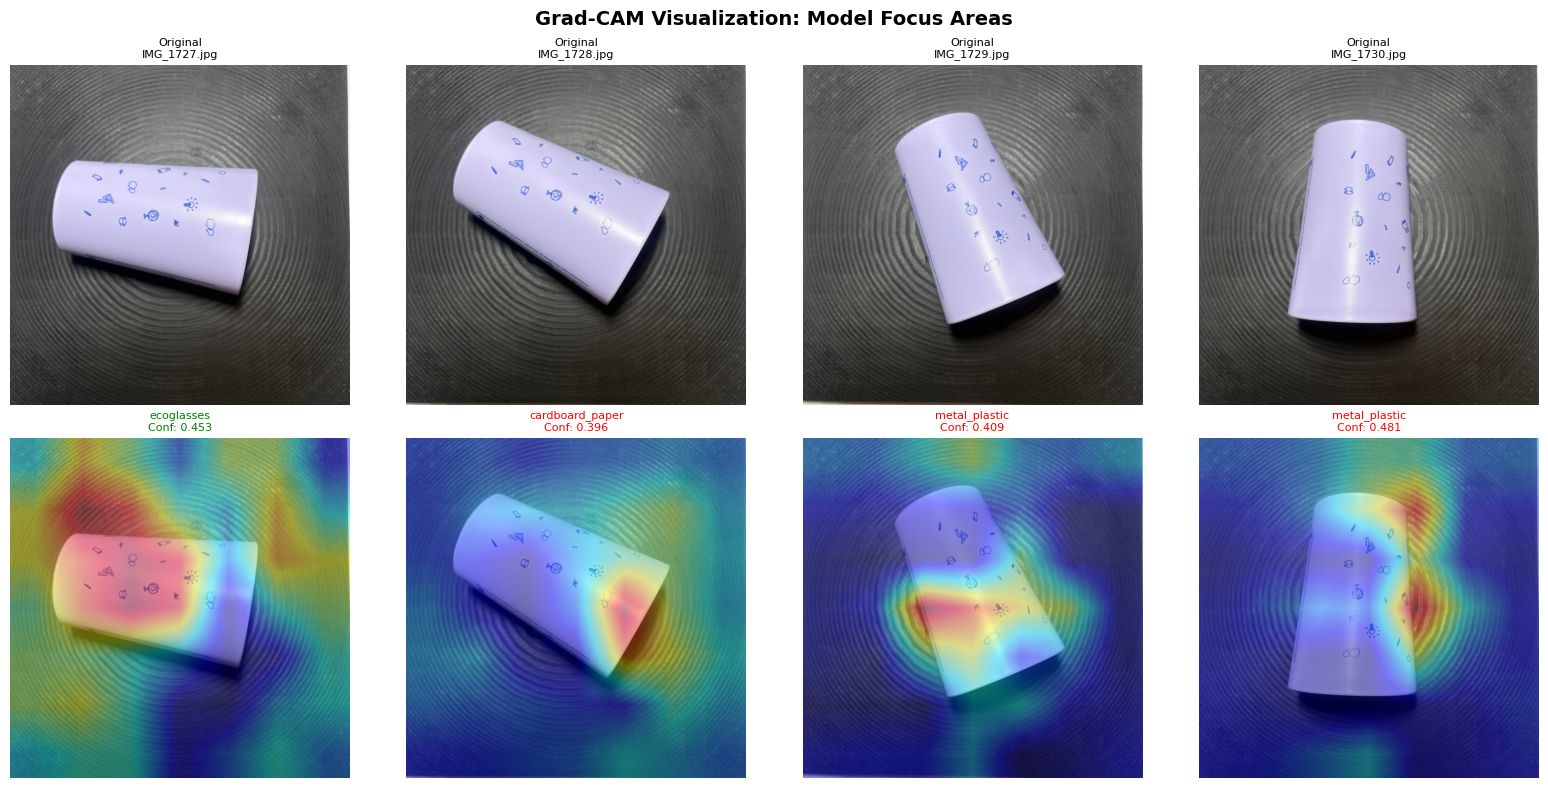


Grad-CAM Interpretation:
- Red/Yellow regions: High importance for classification
- Blue/Purple regions: Low importance
- The heatmap shows which parts of the image influenced the model's decision


In [5]:
from src.inference.gradcam import GradCAMPredictor
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

# Initialize Grad-CAM predictor
gradcam_predictor = GradCAMPredictor(predictor)

# Test on ecoglasses images
ecoglasses_dir = Path('../data/custom/ecoglasses_bandeja_jpg')
test_images = sorted(list(ecoglasses_dir.glob('*.jpg')))[:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, img_path in enumerate(test_images):
    # Load image
    image = cv2.imread(str(img_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Get prediction with Grad-CAM
    result, gradcam_overlay = gradcam_predictor.predict_with_cam(image_rgb)
    
    # Display original
    axes[0, idx].imshow(image_rgb)
    axes[0, idx].set_title(f"Original\n{img_path.name}", fontsize=8)
    axes[0, idx].axis('off')
    
    # Display Grad-CAM overlay
    axes[1, idx].imshow(gradcam_overlay)
    axes[1, idx].set_title(
        f"{result['class_name']}\nConf: {result['confidence']:.3f}", 
        fontsize=8,
        color='green' if result['class_name'] == 'ecoglasses' else 'red'
    )
    axes[1, idx].axis('off')

plt.suptitle('Grad-CAM Visualization: Model Focus Areas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nGrad-CAM Interpretation:")
print("- Red/Yellow regions: High importance for classification")
print("- Blue/Purple regions: Low importance")
print("- The heatmap shows which parts of the image influenced the model's decision")

## 3. Real-time Camera Demo

In [6]:
# Start camera inference
# Press 'q' to quit window

#para imprimir las probabilidades descomentar línea 110 de predictor.py
camera = CameraInference(predictor, camera_id=0)
camera.run()

## 3.5 Real-time Camera Demo with Grad-CAM and Arduino Integration

**Características:**
- ✅ Detección de estabilidad: Solo envía al Arduino después de 4-5 segundos de la misma clasificación
- ✅ Zoom digital: Usa '+' y '-' para hacer zoom in/out (1.0x a 3.0x)
- ✅ Visualización Grad-CAM: Toggle con 'g'
- ✅ Indicador visual cuando la clasificación es estable (✓ STABLE)

In [12]:
from src.inference.camera_gradcam import CameraInferenceWithGradCAM

# Para cámara normal (mono):
camera = CameraInferenceWithGradCAM(predictor, camera_id=0, enable_gradcam=True, stereo_mode='left')

# Para cámara ESTÉREO - usar solo la vista izquierda:
# camera = CameraInferenceWithGradCAM(predictor, camera_id=0, enable_gradcam=True, stereo_mode='left')

# Para cámara ESTÉREO - usar solo la vista derecha:
# camera = CameraInferenceWithGradCAM(predictor, camera_id=0, enable_gradcam=True, stereo_mode='right')

camera.run()  # Press 'g' to toggle, 'q' to quit, 's' to save

### Camera with Grad-CAM (without Arduino)

Basic camera inference with Grad-CAM visualization and zoom functionality.

### 📷 Nota sobre Cámaras Estéreo

Si tu cámara es **estéreo** (envía dos vistas lado a lado), el zoom puede verse como un movimiento lateral en lugar de acercamiento. 

**Solución:** Configura `stereo_mode='left'` o `stereo_mode='right'` para usar solo una de las dos cámaras.

```python
# Cámara ESTÉREO - usar vista izquierda
camera = CameraInferenceWithGradCAM(predictor, camera_id=0, stereo_mode='left')

# Cámara MONO (normal) - dejar en None
camera = CameraInferenceWithGradCAM(predictor, camera_id=0, stereo_mode=None)
```

In [5]:
from src.inference.camera_gradcam import CameraInferenceWithGradCAM

class CameraInferenceWithArduino(CameraInferenceWithGradCAM):
    """Extiende CameraInferenceWithGradCAM para enviar instrucciones al Arduino."""
    
    def __init__(self, predictor, arduino_controller, camera_id=0, enable_gradcam=True, stability_duration=4.0):
        super().__init__(predictor, camera_id=camera_id, enable_gradcam=enable_gradcam, stability_duration=stability_duration)
        self.arduino = arduino_controller
    
    def process_frame(self, result):
        """Override de process_frame para incluir envío al Arduino cuando hay estabilidad."""
        # Solo enviar si hay una clase estable y es diferente de la última enviada
        if 'stable_class' in result:
            stable_class = result['stable_class']
            class_name = self.predictor.class_mapping.get(stable_class, f"Class {stable_class}")
            
            print(f"\n🎯 Clasificación ESTABLE detectada: {class_name} (ID: {stable_class})")
            
            if self.arduino and self.arduino.ser:
                success = self.arduino.send_instruction(stable_class)
                if success:
                    self.last_sent_class = stable_class
                    print(f"✅ Instrucción enviada al Arduino exitosamente")
                else:
                    print(f"❌ Error al enviar instrucción al Arduino")
            else:
                print(f"⚠️  Arduino no conectado - simulando envío de: {stable_class}")
                self.last_sent_class = stable_class

# Crear instancia de cámara con Arduino integrado
# stability_duration: segundos que la misma clase debe mantenerse para enviar al Arduino
if arduino and arduino.ser:
    camera_arduino = CameraInferenceWithArduino(
        predictor, 
        arduino, 
        camera_id=0, 
        enable_gradcam=True,
        stability_duration=4.0  # Esperar 4 segundos de clasificación estable
    )
    print("🚀 Iniciando cámara con control Arduino")
    print("📋 La clasificación se enviará al Arduino después de 4 segundos de estabilidad")
    print("🎮 Controles:")
    print("   - 'q': Salir")
    print("   - 'g': Toggle Grad-CAM")
    print("   - 's': Guardar frame")
    print("   - '+'/'-': Zoom in/out")
    camera_arduino.run()
else:
    print("⚠ Arduino no disponible. Ejecutar cámara sin Arduino...")
    camera = CameraInferenceWithGradCAM(predictor, camera_id=0, enable_gradcam=True, stability_duration=4.0)
    print("🎮 Controles:")
    print("   - 'q': Salir")
    print("   - 'g': Toggle Grad-CAM")
    print("   - 's': Guardar frame")
    print("   - '+'/'-': Zoom in/out")
    camera.run()

⚠ Arduino no disponible. Ejecutar cámara sin Arduino...
🎮 Controles:
   - 'q': Salir
   - 'g': Toggle Grad-CAM
   - 's': Guardar frame
   - '+'/'-': Zoom in/out


c:\Users\tomas\OneDrive\Documents\GitHub\TP-final-vision\.venv\Lib\site-packages\torch\nn\modules\module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


### Ajustar Parámetros de Estabilidad

Puedes modificar estos parámetros según tus necesidades:

```python
# stability_duration: Segundos que debe mantenerse la misma clase (default: 4.0)
# min_confidence: Confianza mínima para considerar predicción válida (default: 0.7)
```

**Recomendaciones:**
- **stability_duration = 3.0**: Para respuesta más rápida (menos estable)
- **stability_duration = 5.0**: Para mayor precisión (más lenta)
- **min_confidence = 0.8**: Para ser más exigente con las predicciones

In [ ]:
# Ejemplo: Configuración personalizada para respuesta más rápida
# Descomentar para usar

# if arduino and arduino.ser:
#     camera_fast = CameraInferenceWithArduino(
#         predictor, 
#         arduino, 
#         camera_id=0, 
#         enable_gradcam=True,
#         stability_duration=3.0  # Solo 3 segundos de estabilidad
#     )
#     camera_fast.run()
# else:
#     print("Arduino no conectado")

In [11]:
from src.inference.camera_gradcam import CameraInferenceWithGradCAM

class CameraInferenceWithArduino(CameraInferenceWithGradCAM):
    """Extiende CameraInferenceWithGradCAM para enviar instrucciones al Arduino."""
    
    def __init__(self, predictor, arduino_controller, camera_id=0, enable_gradcam=True, 
                 stability_duration=4.0, stereo_mode=None, width=1280, height=1280):
        super().__init__(predictor, camera_id=camera_id, enable_gradcam=enable_gradcam, 
                        stability_duration=stability_duration, stereo_mode=stereo_mode, width=width, height=height)
        self.arduino = arduino_controller
    
    def process_frame(self, result):
        """Override de process_frame para incluir envío al Arduino cuando hay estabilidad."""
        if 'stable_class' in result:
            stable_class = result['stable_class']
            class_name = self.predictor.class_mapping.get(stable_class, f"Class {stable_class}")
            
            print(f"\n🎯 Clasificación ESTABLE: {class_name} (ID: {stable_class})")
            
            if self.arduino and self.arduino.ser:
                success = self.arduino.send_instruction(stable_class)
                if success:
                    self.last_sent_class = stable_class
                    print(f"✅ Enviado al Arduino")
            else:
                print(f"⚠️  Arduino no conectado")
                self.last_sent_class = stable_class

# 🔧 CONFIGURAR AQUÍ: stereo_mode='left' o 'right' para cámara estéreo, None para mono
STEREO_MODE = 'left'  # Mono por defecto

if arduino and arduino.ser:
    print(f"🚀 Iniciando cámara con Arduino - Modo: {STEREO_MODE or 'MONO'}")
    camera_arduino = CameraInferenceWithArduino(
        predictor, arduino, camera_id=0, enable_gradcam=True,
        stability_duration=4.0, stereo_mode=STEREO_MODE, width=2040, height=2040
    )
    print(f"🚀 Cámara con Arduino - Modo: {STEREO_MODE or 'MONO'}")
    camera_arduino.run()
else:
    print("⚠ Arduino no disponible")
    camera = CameraInferenceWithGradCAM(
        predictor, camera_id=0, enable_gradcam=True, 
        stability_duration=4.0, stereo_mode=STEREO_MODE
    )
    camera.run()

🚀 Iniciando cámara con Arduino - Modo: left
🚀 Cámara con Arduino - Modo: left

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)
✗ Arduino no conectado

🎯 Clasificación ESTABLE: trash (ID: 3)


## 4. Manual Single Prediction with Arduino Control

Test individual images and manually send instructions to Arduino.

In [10]:
arduino.close()

✓ Conexión cerrada
